# LAB 05: PHÂN ĐOẠN ẢNH (IMAGE SEGMENTATION)


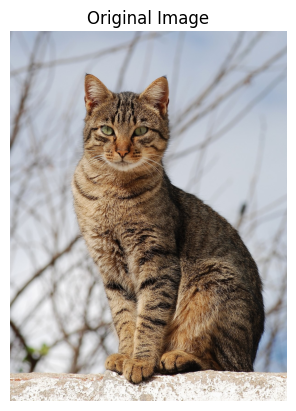

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as An

img = cv2.imread('cat.jpg')
img2 = cv2.imread('dog.jpg')

def show_img(image, title='Image', cmap=None):
    if image is None: return
    if len(image.shape) == 3 and cmap is None:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        An.imshow(image)
    else:
        An.imshow(image, cmap=cmap if cmap else 'gray')
    An.title(title)
    An.axis('off')
    An.show()

if img is not None:
    show_img(img, "Original Image")

## 1. Thresholding để phân đoạn ảnh


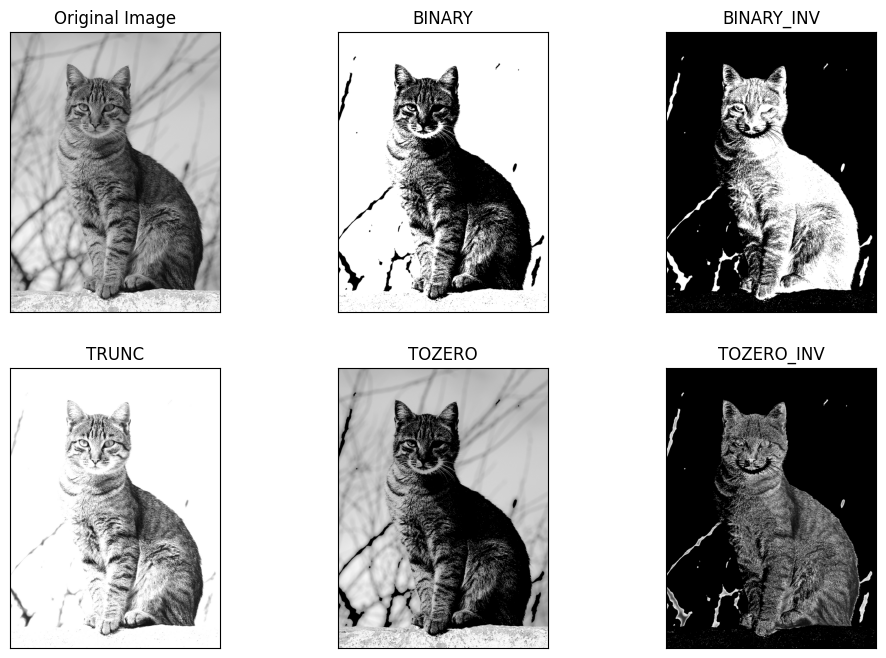

In [9]:
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, thresh1 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    ret, thresh2 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    ret, thresh3 = cv2.threshold(gray, 127, 255, cv2.THRESH_TRUNC)
    ret, thresh4 = cv2.threshold(gray, 127, 255, cv2.THRESH_TOZERO)
    ret, thresh5 = cv2.threshold(gray, 127, 255, cv2.THRESH_TOZERO_INV)
    titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
    images = [gray, thresh1, thresh2, thresh3, thresh4, thresh5]
    An.figure(figsize=(12, 8))
    for i in range(6):
        An.subplot(2, 3, i+1)
        An.imshow(images[i], 'gray')
        An.title(titles[i])
        An.xticks([]), An.yticks([])
    An.show()

## 2. Otsu Algorithm để phân đoạn ảnh vân tay


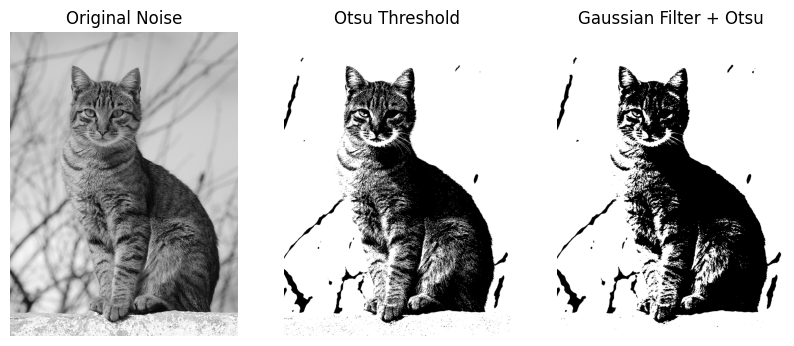

In [10]:
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret2, th2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    ret3, th3 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    An.figure(figsize=(10, 6))
    An.subplot(1, 3, 1), An.imshow(gray, 'gray'), An.title('Original Noise'), An.axis('off')
    An.subplot(1, 3, 2), An.imshow(th2, 'gray'), An.title('Otsu Threshold'), An.axis('off')
    An.subplot(1, 3, 3), An.imshow(th3, 'gray'), An.title('Gaussian Filter + Otsu'), An.axis('off')
    An.show()

## 3. Clustering techniques trong phân đoạn ảnh, K-mean clustering


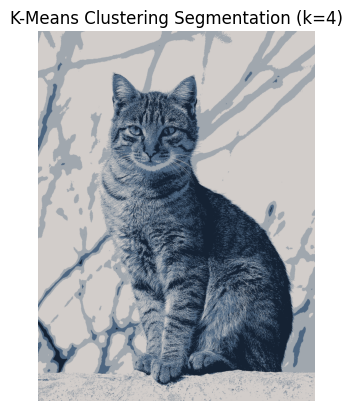

In [11]:
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pixel_values = img_rgb.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    k = 4
    _, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)
    labels = labels.flatten()
    segmented_image = centers[labels.flatten()]
    segmented_image = segmented_image.reshape(img_rgb.shape)
    show_img(segmented_image, f"K-Means Clustering Segmentation (k={k})")

## 4. Region расту (Region Growing)


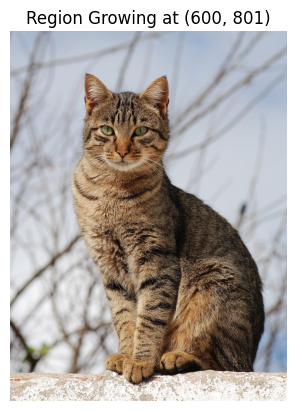

In [12]:
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape[:2]
    seed_point = (w // 2, h // 2)
    mask = np.zeros((h + 2, w + 2), np.uint8)
    flood_img = img.copy()
    cv2.floodFill(flood_img, mask, seed_point, (0, 255, 0), (15, 15, 15), (15, 15, 15), flags=4)
    show_img(flood_img, f"Region Growing at {seed_point}")

## 5. Phân đoạn ảnh với Split and Merge


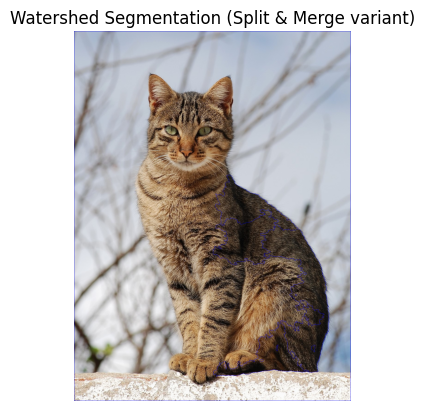

In [13]:
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    ret, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    img_watershed = img.copy()
    markers = cv2.watershed(img_watershed, markers)
    img_watershed[markers == -1] = [255, 0, 0]
    show_img(img_watershed, "Watershed Segmentation (Split & Merge variant)")

## 6. Edge-based segmentation


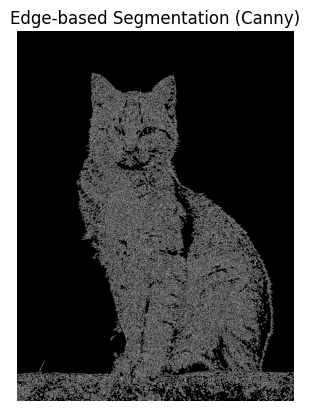

In [14]:
if img is not None:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    show_img(edges, "Edge-based Segmentation (Canny)", cmap='gray')